# Phase 3B Statistical Baseline: Categorical Stimulus Model

This notebook fits the first Bayesian mixed-effects model for the synthetic rating data generated in Notebook 1. The analysis is an effect-recovery and pipeline-validation exercise only. The estimates are not empirical findings about real participants, real mix preferences, or perceptual properties of the final audio stimuli.

## 1. Imports, Runtime Configuration, and Reproducibility

The notebook uses Bambi with PyMC and the CPU `nutpie` NUTS backend. `nutpie` is used because the available Windows Python environment does not expose a working PyTensor C++ compiler. Sampling remains CPU-based and produces standard ArviZ `InferenceData` outputs.

In [1]:
from __future__ import annotations

import importlib.metadata as metadata
import json
import os
import re
import sys
import time
import warnings
from pathlib import Path

CACHE_ROOT = Path(os.environ.get("TEMP", ".")) / "nb2cache"
(CACHE_ROOT / "pt" / "numba").mkdir(parents=True, exist_ok=True)
(CACHE_ROOT / "nb").mkdir(parents=True, exist_ok=True)
os.environ.setdefault("PYTENSOR_FLAGS", f"cxx=,base_compiledir={(CACHE_ROOT / 'pt').as_posix()}")
os.environ.setdefault("NUMBA_CACHE_DIR", str(CACHE_ROOT / "nb"))

import arviz as az
import bambi as bmb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
from IPython.display import display

SEED = 42
rng = np.random.default_rng(SEED)
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)
az.rcParams["plot.max_subplots"] = 40

SAMPLING_CONFIG = {
    "draws": 1000,
    "tune": 1000,
    "chains": 4,
    "cores": 1,
    "target_accept": 0.95,
    "random_seed": SEED,
    "inference_method": "nutpie",
}

def package_version(package_name: str) -> str:
    try:
        return metadata.version(package_name)
    except metadata.PackageNotFoundError:
        return "not installed"

version_report = pd.DataFrame(
    [
        {"component": "Python", "version": sys.version.split()[0]},
        {"component": "Bambi", "version": bmb.__version__},
        {"component": "PyMC", "version": pm.__version__},
        {"component": "ArviZ", "version": az.__version__},
        {"component": "NumPy", "version": np.__version__},
        {"component": "pandas", "version": pd.__version__},
        {"component": "matplotlib", "version": metadata.version("matplotlib")},
        {"component": "nutpie", "version": package_version("nutpie")},
    ]
)
display(version_report)
display(pd.DataFrame([SAMPLING_CONFIG]))
print(f"PyTensor/Numba cache root: {CACHE_ROOT}")

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`


,component,version
0,Python,3.13.9
1,Bambi,0.17.2
2,PyMC,5.28.5
3,ArviZ,0.23.4
4,NumPy,2.3.5
5,pandas,2.3.3
6,matplotlib,3.10.6
7,nutpie,0.16.11


,draws,tune,chains,cores,target_accept,random_seed,inference_method
0,1000,1000,4,1,0.95,42,nutpie


PyTensor/Numba cache root: C:\Users\oscar\AppData\Local\Temp\nb2cache


## 2. Project-Relative Paths

Paths are resolved from the repository root, not from the current notebook launch directory.

In [2]:
def find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd().resolve() if start is None else start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "configs" / "stimulus_selection.yaml").exists() and (candidate / "README.md").exists():
            return candidate
    raise FileNotFoundError("Could not locate repository root from the current working directory.")

REPO_ROOT = find_repo_root()
SYNTHETIC_DIR = REPO_ROOT / "data" / "processed" / "synthetic" / "statistical_baseline"
OUTPUT_DIR = REPO_ROOT / "outputs" / "statistical_baseline" / "categorical_model"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ratings_path_candidates = sorted(SYNTHETIC_DIR.glob("*ratings*.csv"))
if not ratings_path_candidates:
    raise FileNotFoundError(f"No ratings CSV found in {SYNTHETIC_DIR}")
RATINGS_PATH = next((p for p in ratings_path_candidates if p.name == "synthetic_ratings_seed42.csv"), ratings_path_candidates[0])

print(f"Repository root: {REPO_ROOT}")
print(f"Ratings source: {RATINGS_PATH.relative_to(REPO_ROOT)}")
print(f"Model output directory: {OUTPUT_DIR.relative_to(REPO_ROOT)}")

Repository root: C:\Users\oscar\Documents\7. QMUL UNIVERSITY\1. Master Program\3. MSc Project\intent2control-dissertation
Ratings source: data\processed\synthetic\statistical_baseline\synthetic_ratings_seed42.csv
Model output directory: outputs\statistical_baseline\categorical_model


## 3. Load and Validate Synthetic Ratings

The modelling source of truth is the rating-level CSV exported by Notebook 1. Required modelling columns are checked directly from the exported file.

In [3]:
ratings_df = pd.read_csv(RATINGS_PATH)
REQUIRED_COLUMNS = ["participant_id", "group", "song_id", "mix_id", "stimulus_id", "episode", "rating"]
missing_columns = sorted(set(REQUIRED_COLUMNS) - set(ratings_df.columns))
if missing_columns:
    raise ValueError(f"Missing required modelling columns: {missing_columns}")

trial_columns = ["participant_id", "group", "song_id", "episode"]
validation_rows = []

def add_check(check: str, passed: bool, observed: object, expected: object) -> None:
    validation_rows.append({"check": check, "passed": bool(passed), "observed": observed, "expected": expected})

add_check("rating_rows", len(ratings_df) == 1200, len(ratings_df), 1200)
add_check("participants", ratings_df["participant_id"].nunique() == 40, ratings_df["participant_id"].nunique(), 40)
add_check("songs", ratings_df["song_id"].nunique() == 4, ratings_df["song_id"].nunique(), 4)
add_check("unique_stimuli", ratings_df["stimulus_id"].nunique() == 12, ratings_df["stimulus_id"].nunique(), 12)
add_check("episodes", ratings_df["episode"].nunique() == 5, ratings_df["episode"].nunique(), 5)
add_check(
    "three_mixes_per_participant_song_episode_trial",
    ratings_df.groupby(trial_columns)["mix_id"].nunique().eq(3).all(),
    ratings_df.groupby(trial_columns)["mix_id"].nunique().unique().tolist(),
    3,
)
add_check("ratings_between_0_and_100", ratings_df["rating"].between(0, 100).all(), "all checked", "0 <= rating <= 100")
add_check("no_missing_modelling_values", ratings_df[REQUIRED_COLUMNS].notna().all().all(), ratings_df[REQUIRED_COLUMNS].isna().sum().to_dict(), "all zero")
validation_df = pd.DataFrame(validation_rows)
display(validation_df)
assert validation_df["passed"].all()

,check,passed,observed,expected
0,rating_rows,True,1200,1200
1,participants,True,40,40
2,songs,True,4,4
3,unique_stimuli,True,12,12
4,episodes,True,5,5
5,three_mixes_per_participant_song_episode_trial,True,[3],3
6,ratings_between_0_and_100,True,all checked,0 <= rating <= 100
7,no_missing_modelling_values,True,"{'participant_id': 0, 'group': 0, 'song_id': 0...",all zero


## 4. Modelling Choice

Repeated ratings from the same participant violate the independence assumption of an ordinary fixed-effects regression. A mixed-effects model accounts for this by estimating a participant-level random intercept, allowing each participant to have their own baseline rating tendency while sharing information across participants.

The primary categorical baseline uses `stimulus_id` rather than treating `Mix_1`, `Mix_2`, and `Mix_3` as equivalent profiles across songs. The neutral mix identifiers identify slots within each song and must not be interpreted as stable perceptual categories across songs. The Episode x Stimulus interaction estimates context-dependent differences among the twelve study stimuli.

Because `stimulus_id` already identifies a specific song-mix combination, song identity is included inside the stimulus term. A separate song fixed effect is not included in the primary model, avoiding redundant categorical structure. This model can predict known study stimuli, but it cannot explain preference using MST features.

## 5. Prepare Categorical Variables

Explicit reference levels make treatment-coded coefficients reproducible. The references are neutral design anchors, not perceptual baselines.

In [4]:
EPISODE_LEVELS = ["Relaxation", "Distraction", "Enjoyment", "Focus", "Motivation"]
GROUP_LEVELS = ["Group_1", "Group_2"]
SONG_LEVELS = ["Song_1", "Song_2", "Song_3", "Song_4"]
MIX_LEVELS = ["Mix_1", "Mix_2", "Mix_3"]
STIMULUS_LEVELS = [f"{song}_{mix}" for song in SONG_LEVELS for mix in MIX_LEVELS]
PARTICIPANT_LEVELS = sorted(ratings_df["participant_id"].unique())
category_levels = {
    "participant_id": PARTICIPANT_LEVELS,
    "group": GROUP_LEVELS,
    "song_id": SONG_LEVELS,
    "mix_id": MIX_LEVELS,
    "stimulus_id": STIMULUS_LEVELS,
    "episode": EPISODE_LEVELS,
}
model_df = ratings_df.copy()
for column, levels in category_levels.items():
    model_df[column] = pd.Categorical(model_df[column], categories=levels, ordered=False)

category_summary = pd.DataFrame(
    [
        {"variable": "participant_id", "number_of_levels": len(PARTICIPANT_LEVELS), "reference_level": PARTICIPANT_LEVELS[0], "interpretation": "random-intercept grouping factor"},
        {"variable": "group", "number_of_levels": len(GROUP_LEVELS), "reference_level": GROUP_LEVELS[0], "interpretation": "design allocation; not used as a fixed effect in the primary model"},
        {"variable": "song_id", "number_of_levels": len(SONG_LEVELS), "reference_level": SONG_LEVELS[0], "interpretation": "song identifier embedded in stimulus_id"},
        {"variable": "mix_id", "number_of_levels": len(MIX_LEVELS), "reference_level": MIX_LEVELS[0], "interpretation": "neutral within-song mix slot; not interpreted across songs"},
        {"variable": "stimulus_id", "number_of_levels": len(STIMULUS_LEVELS), "reference_level": STIMULUS_LEVELS[0], "interpretation": "specific song-mix stimulus used as primary categorical predictor"},
        {"variable": "episode", "number_of_levels": len(EPISODE_LEVELS), "reference_level": EPISODE_LEVELS[0], "interpretation": "listening-context episode"},
    ]
)
display(category_summary)
assert not model_df[REQUIRED_COLUMNS].isna().any().any()

,variable,number_of_levels,reference_level,interpretation
0,participant_id,40,P001,random-intercept grouping factor
1,group,2,Group_1,design allocation; not used as a fixed effect ...
2,song_id,4,Song_1,song identifier embedded in stimulus_id
3,mix_id,3,Mix_1,neutral within-song mix slot; not interpreted ...
4,stimulus_id,12,Song_1_Mix_1,specific song-mix stimulus used as primary cat...
5,episode,5,Relaxation,listening-context episode


## 6. Outcome Inspection Before Modelling

These descriptive summaries check the synthetic outcome before fitting. They are not empirical participant findings.

In [5]:
outcome_summary = pd.DataFrame(
    [
        {"measure": "mean", "value": model_df["rating"].mean()},
        {"measure": "standard_deviation", "value": model_df["rating"].std()},
        {"measure": "minimum", "value": model_df["rating"].min()},
        {"measure": "maximum", "value": model_df["rating"].max()},
        {"measure": "count_rating_le_5", "value": int(model_df["rating"].le(5).sum())},
        {"measure": "count_rating_ge_95", "value": int(model_df["rating"].ge(95).sum())},
    ]
)
outcome_summary["value"] = outcome_summary["value"].round(3)
episode_summary = model_df.groupby("episode", observed=False)["rating"].agg(count="count", mean="mean", sd="std").round(2).reset_index()
stimulus_summary = model_df.groupby("stimulus_id", observed=False)["rating"].agg(count="count", mean="mean", sd="std").round(2).reset_index()
episode_stimulus_summary = model_df.groupby(["episode", "stimulus_id"], observed=False)["rating"].agg(count="count", mean="mean", sd="std").round(2).reset_index()
display(outcome_summary)
display(episode_summary)
display(stimulus_summary)

,measure,value
0,mean,66.735
1,standard_deviation,12.977
2,minimum,23.200
3,maximum,100.000
4,count_rating_le_5,0.000
5,count_rating_ge_95,20.000


,episode,count,mean,sd
0,Relaxation,240,65.59,12.87
1,Distraction,240,63.66,12.88
2,Enjoyment,240,68.69,12.42
3,Focus,240,68.00,13.36
4,Motivation,240,67.73,12.78


,stimulus_id,count,mean,sd
0,Song_1_Mix_1,100,62.87,11.75
1,Song_1_Mix_2,100,65.46,12.34
2,Song_1_Mix_3,100,61.16,13.40
3,Song_2_Mix_1,100,64.18,11.71
4,Song_2_Mix_2,100,67.60,11.52
5,Song_2_Mix_3,100,63.65,12.87
6,Song_3_Mix_1,100,74.09,12.67
7,Song_3_Mix_2,100,74.78,10.74
8,Song_3_Mix_3,100,74.52,12.19
9,Song_4_Mix_1,100,63.75,11.71


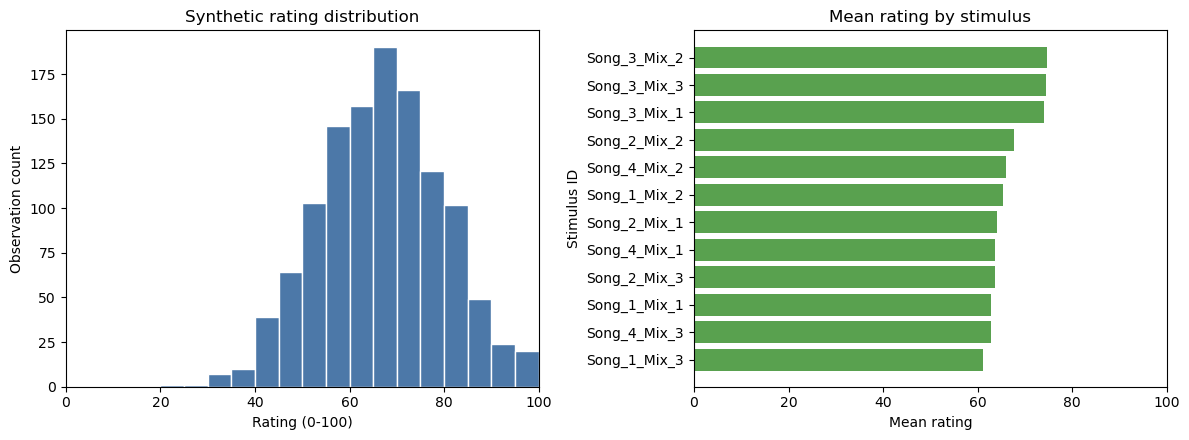

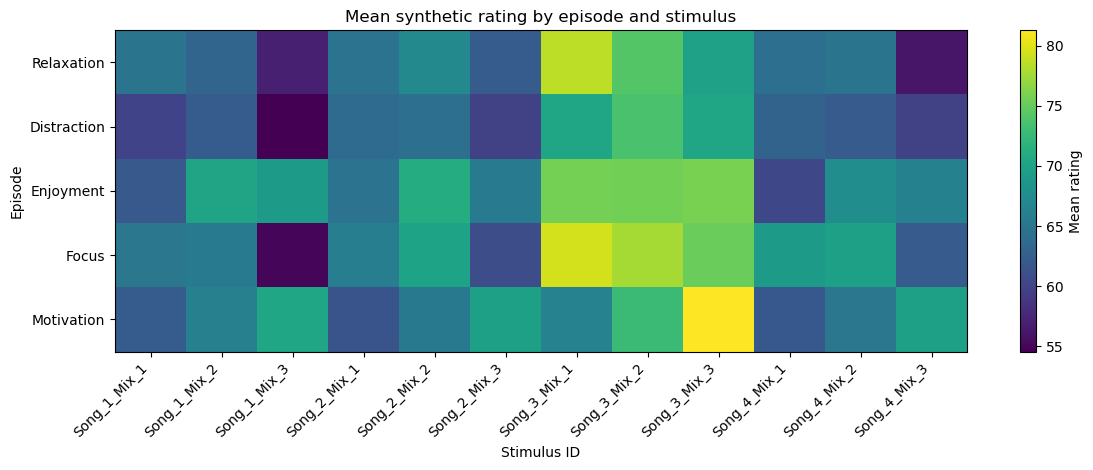

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(model_df["rating"], bins=np.arange(0, 105, 5), color="#4C78A8", edgecolor="white")
axes[0].set_title("Synthetic rating distribution")
axes[0].set_xlabel("Rating (0-100)")
axes[0].set_ylabel("Observation count")
axes[0].set_xlim(0, 100)
stimulus_order_by_mean = stimulus_summary.sort_values("mean")["stimulus_id"]
axes[1].barh(stimulus_order_by_mean, stimulus_summary.set_index("stimulus_id").loc[stimulus_order_by_mean, "mean"], color="#59A14F")
axes[1].set_title("Mean rating by stimulus")
axes[1].set_xlabel("Mean rating")
axes[1].set_ylabel("Stimulus ID")
axes[1].set_xlim(0, 100)
fig.tight_layout()
plt.show()

mean_heatmap = episode_stimulus_summary.pivot(index="episode", columns="stimulus_id", values="mean").loc[EPISODE_LEVELS, STIMULUS_LEVELS]
fig, ax = plt.subplots(figsize=(12, 4.8))
im = ax.imshow(mean_heatmap.to_numpy(), aspect="auto", cmap="viridis")
ax.set_xticks(range(len(STIMULUS_LEVELS)))
ax.set_xticklabels(STIMULUS_LEVELS, rotation=45, ha="right")
ax.set_yticks(range(len(EPISODE_LEVELS)))
ax.set_yticklabels(EPISODE_LEVELS)
ax.set_title("Mean synthetic rating by episode and stimulus")
ax.set_xlabel("Stimulus ID")
ax.set_ylabel("Episode")
fig.colorbar(im, ax=ax, label="Mean rating")
fig.tight_layout()
plt.show()

## 7. Priors

The first pass uses Bambi's default weakly regularising priors for a Gaussian model. These defaults are automatically scaled from the response and design matrix; they are suitable for a pipeline-validation model and avoid imposing strong prior beliefs about neutral stimulus effects.

In [7]:
intercept_model = bmb.Model("rating ~ 1 + (1 | participant_id)", model_df, family="gaussian")
categorical_model = bmb.Model("rating ~ episode * stimulus_id + (1 | participant_id)", model_df, family="gaussian")
print("Intercept-only model priors:")
intercept_model.build()
print(intercept_model)
print("\nCategorical Episode x Stimulus model priors:")
categorical_model.build()
print(categorical_model)

Intercept-only model priors:
       Formula: rating ~ 1 + (1 | participant_id)
        Family: gaussian
          Link: mu = identity
  Observations: 1200
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 66.7346, sigma: 32.4295)
        
        Group-level effects
            1|participant_id ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 32.4295))
        
        Auxiliary parameters
            sigma ~ HalfStudentT(nu: 4.0, sigma: 12.9718)

Categorical Episode x Stimulus model priors:
       Formula: rating ~ episode * stimulus_id + (1 | participant_id)
        Family: gaussian
          Link: mu = identity
  Observations: 1200
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 66.7346, sigma: 62.764)
            episode ~ Normal(mu: [0. 0. 0. 0.], sigma: [81.0737 81.0737 81.0737 81.0737])
            stimulus_id ~ Normal(mu: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.], sigma: [117.3343 117.3343 117.33

## 8. Intercept-Only Mixed Model

The intercept-only model is a debugging and variance-decomposition model. It estimates the overall rating mean, participant-to-participant variability, residual variability, and the intraclass correlation coefficient (ICC).

In [8]:
def fit_model(model: bmb.Model, label: str):
    print(f"Fitting {label}...")
    started = time.time()
    idata = model.fit(progressbar=False, **SAMPLING_CONFIG)
    elapsed = time.time() - started
    print(f"Finished {label} in {elapsed / 60:.2f} minutes.")
    return idata, elapsed

intercept_idata, intercept_elapsed_seconds = fit_model(intercept_model, "intercept-only mixed model")

Fitting intercept-only mixed model...


Finished intercept-only mixed model in 0.11 minutes.


In [9]:
def posterior_var_values(idata, candidates: list[str]) -> np.ndarray:
    for name in candidates:
        if name in idata.posterior:
            return idata.posterior[name].values.reshape(-1)
    pattern = re.compile("|".join(re.escape(candidate) for candidate in candidates))
    for name in idata.posterior.data_vars:
        if pattern.search(name):
            return idata.posterior[name].values.reshape(-1)
    raise KeyError(f"Could not find any posterior variable matching {candidates}. Available: {list(idata.posterior.data_vars)}")

participant_sd = posterior_var_values(intercept_idata, ["1|participant_id_sigma"])
residual_sd = posterior_var_values(intercept_idata, ["sigma"])
intercept_values = posterior_var_values(intercept_idata, ["Intercept"])
icc_values = participant_sd**2 / (participant_sd**2 + residual_sd**2)
intercept_variance_summary = pd.DataFrame(
    [
        {"quantity": "intercept", "mean": intercept_values.mean(), "hdi_3%": np.quantile(intercept_values, 0.03), "hdi_97%": np.quantile(intercept_values, 0.97)},
        {"quantity": "participant_sd", "mean": participant_sd.mean(), "hdi_3%": np.quantile(participant_sd, 0.03), "hdi_97%": np.quantile(participant_sd, 0.97)},
        {"quantity": "residual_sd", "mean": residual_sd.mean(), "hdi_3%": np.quantile(residual_sd, 0.03), "hdi_97%": np.quantile(residual_sd, 0.97)},
        {"quantity": "ICC", "mean": icc_values.mean(), "hdi_3%": np.quantile(icc_values, 0.03), "hdi_97%": np.quantile(icc_values, 0.97)},
    ]
).round(3)
display(intercept_variance_summary)

,quantity,mean,hdi_3%,hdi_97%
0,intercept,66.719,64.428,68.978
1,participant_sd,7.524,5.943,9.472
2,residual_sd,10.797,10.387,11.226
3,ICC,0.326,0.231,0.438


The ICC is the estimated proportion of total rating variance attributable to stable participant-level differences in baseline rating tendency. In this repeated-rating design, a non-zero ICC is expected because each participant contributes 30 ratings.

## 9. Primary Categorical Stimulus Model

The primary model is:

`rating ~ episode * stimulus_id + (1 | participant_id)`

It estimates context-dependent differences among the twelve known stimuli while allowing each participant to have their own baseline rating tendency.

In [10]:
categorical_idata, categorical_elapsed_seconds = fit_model(categorical_model, "categorical Episode x Stimulus mixed model")

Fitting categorical Episode x Stimulus mixed model...


Finished categorical Episode x Stimulus mixed model in 0.15 minutes.


## 10. Convergence Diagnostics

Diagnostics are summarised compactly. Criteria for a usable fit are maximum R-hat close to 1.00, no divergences, and adequate effective sample sizes. The notebook does not claim convergence if these checks fail.

In [11]:
def diagnostic_table(idata, model_label: str) -> pd.DataFrame:
    summary = az.summary(idata, round_to=3)
    max_rhat = float(summary["r_hat"].max(skipna=True))
    min_bulk_ess = float(summary["ess_bulk"].min(skipna=True))
    min_tail_ess = float(summary["ess_tail"].min(skipna=True))
    divergences = int(idata.sample_stats["diverging"].sum().item()) if "diverging" in idata.sample_stats else 0
    max_tree_depth = float(idata.sample_stats["tree_depth"].max().item()) if "tree_depth" in idata.sample_stats else np.nan
    reached_max_tree_depth = int(idata.sample_stats["reached_max_treedepth"].sum().item()) if "reached_max_treedepth" in idata.sample_stats else 0
    return pd.DataFrame(
        [
            {"model": model_label, "diagnostic": "max_rhat", "value": max_rhat, "criterion": "approximately <= 1.01"},
            {"model": model_label, "diagnostic": "min_bulk_ess", "value": min_bulk_ess, "criterion": "larger is better; inspect if low"},
            {"model": model_label, "diagnostic": "min_tail_ess", "value": min_tail_ess, "criterion": "larger is better; inspect if low"},
            {"model": model_label, "diagnostic": "divergences", "value": divergences, "criterion": "0"},
            {"model": model_label, "diagnostic": "max_tree_depth", "value": max_tree_depth, "criterion": "not at sampler limit"},
            {"model": model_label, "diagnostic": "reached_max_tree_depth", "value": reached_max_tree_depth, "criterion": "0"},
        ]
    )

intercept_diagnostics = diagnostic_table(intercept_idata, "intercept_only")
categorical_diagnostics = diagnostic_table(categorical_idata, "episode_x_stimulus")
combined_diagnostics = pd.concat([intercept_diagnostics, categorical_diagnostics], ignore_index=True)
display(combined_diagnostics)
posterior_summary = az.summary(categorical_idata, round_to=3)
display(posterior_summary.head(20))

,model,diagnostic,value,criterion
0,intercept_only,max_rhat,1.012,approximately <= 1.01
1,intercept_only,min_bulk_ess,364.104,larger is better; inspect if low
2,intercept_only,min_tail_ess,648.991,larger is better; inspect if low
3,intercept_only,divergences,0.000,0
4,intercept_only,max_tree_depth,NaN,not at sampler limit
5,intercept_only,reached_max_tree_depth,0.000,0
6,episode_x_stimulus,max_rhat,1.012,approximately <= 1.01
7,episode_x_stimulus,min_bulk_ess,498.715,larger is better; inspect if low
8,episode_x_stimulus,min_tail_ess,888.031,larger is better; inspect if low
9,episode_x_stimulus,divergences,0.000,0


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,59.753,2.662,55.038,65.002,0.119,0.060,498.715,888.031,1.010
episode[Enjoyment],2.357,2.967,-2.998,8.030,0.123,0.060,581.937,1146.360,1.006
episode[Focus],5.409,3.046,-0.184,11.149,0.132,0.062,537.475,1387.893,1.007
episode[Motivation],2.577,3.102,-3.068,8.411,0.134,0.072,540.610,1072.903,1.009
episode[Relaxation],5.079,3.025,-0.474,10.888,0.133,0.062,516.876,1211.123,1.005
stimulus_id[Song_1_Mix_2],2.545,3.057,-2.772,8.769,0.124,0.054,604.190,1233.343,1.009
stimulus_id[Song_1_Mix_3],-5.142,3.008,-10.881,0.362,0.118,0.049,643.644,1606.276,1.004
stimulus_id[Song_2_Mix_1],4.018,3.088,-1.843,9.625,0.119,0.060,670.143,1327.343,1.005
stimulus_id[Song_2_Mix_2],4.606,3.023,-1.153,10.135,0.119,0.056,639.911,1324.494,1.006
stimulus_id[Song_2_Mix_3],-0.020,3.006,-5.899,5.220,0.115,0.058,683.376,1241.492,1.004


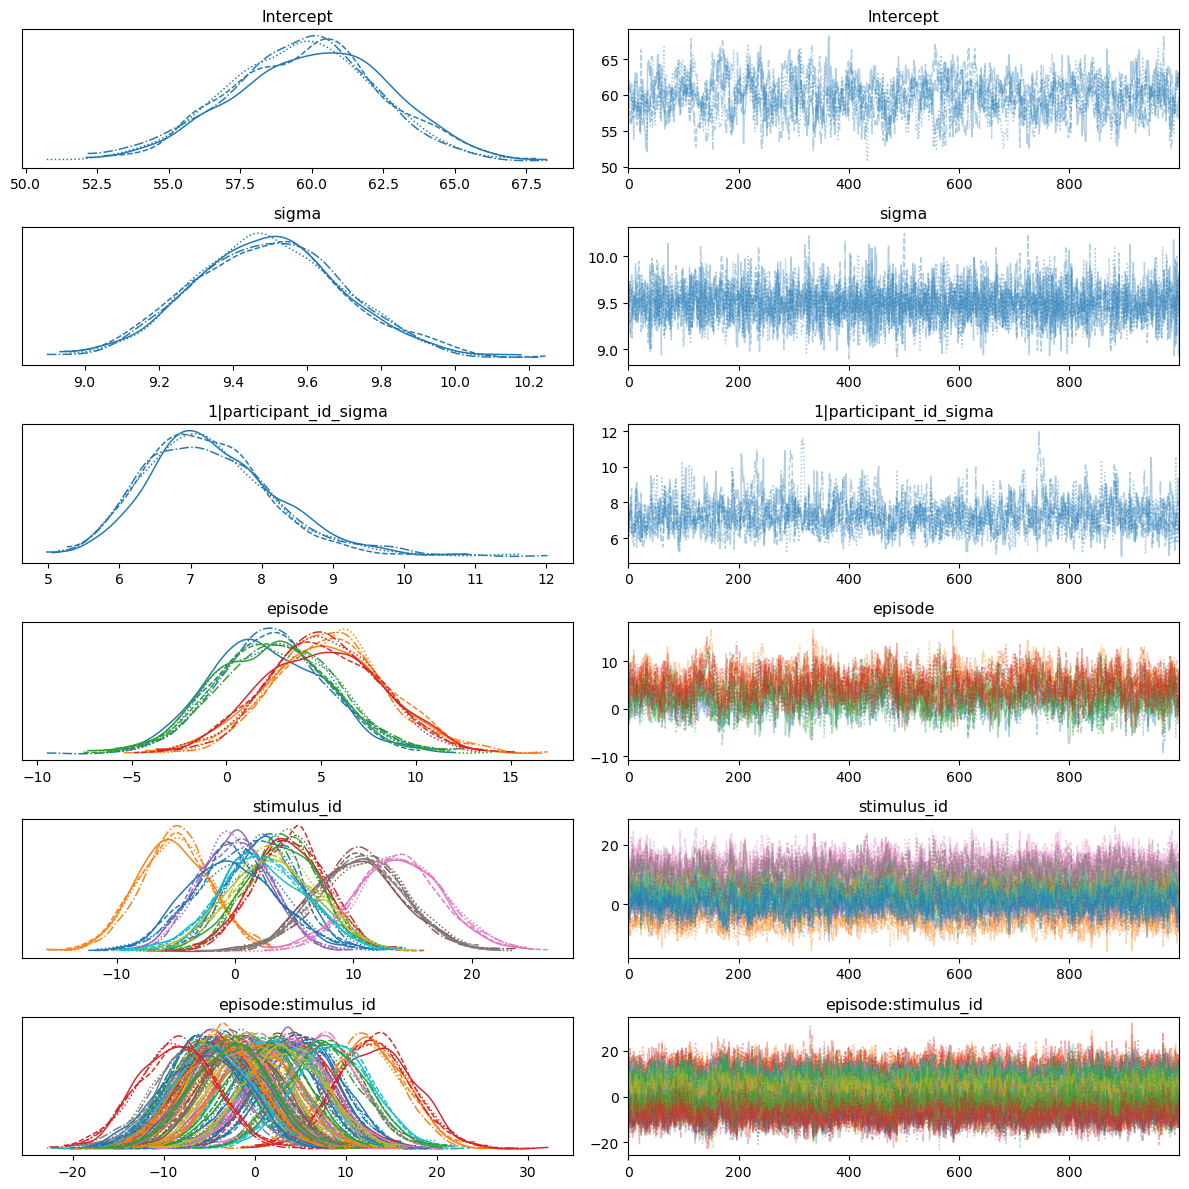

In [12]:
trace_variables = [name for name in ["Intercept", "sigma", "1|participant_id_sigma"] if name in categorical_idata.posterior]
for candidate in [name for name in categorical_idata.posterior.data_vars if name.startswith("episode") or name.startswith("stimulus_id")][:4]:
    trace_variables.append(candidate)
az.plot_trace(categorical_idata, var_names=trace_variables, compact=True)
plt.tight_layout()
plt.show()

## 11. Posterior Predictive Checks

Posterior predictive samples compare observed ratings with simulated ratings from the fitted Gaussian likelihood. Values outside 0-100 are not clipped; their frequency is a boundary-behaviour diagnostic.

In [13]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    categorical_ppc_idata = categorical_model.predict(
        categorical_idata,
        kind="response",
        inplace=False,
        include_group_specific=True,
        random_seed=SEED,
    )

posterior_predictive = categorical_ppc_idata.posterior_predictive["rating"]
ppc_values = posterior_predictive.values
ppc_boundary_violation_rate = float(((ppc_values < 0) | (ppc_values > 100)).mean())
ppc_obs_dim = posterior_predictive.dims[-1]
ppc_mean = posterior_predictive.mean(dim=ppc_obs_dim).values.reshape(-1)
ppc_sd = posterior_predictive.std(dim=ppc_obs_dim).values.reshape(-1)
ppc_summary = pd.DataFrame(
    [
        {"quantity": "observed_mean", "observed": model_df["rating"].mean(), "posterior_predictive_mean": ppc_mean.mean(), "ppc_hdi_3%": np.quantile(ppc_mean, 0.03), "ppc_hdi_97%": np.quantile(ppc_mean, 0.97)},
        {"quantity": "observed_sd", "observed": model_df["rating"].std(), "posterior_predictive_mean": ppc_sd.mean(), "ppc_hdi_3%": np.quantile(ppc_sd, 0.03), "ppc_hdi_97%": np.quantile(ppc_sd, 0.97)},
        {"quantity": "ppc_outside_0_100_proportion", "observed": 0.0, "posterior_predictive_mean": ppc_boundary_violation_rate, "ppc_hdi_3%": np.nan, "ppc_hdi_97%": np.nan},
    ]
).round(4)
display(ppc_summary)

,quantity,observed,posterior_predictive_mean,ppc_hdi_3%,ppc_hdi_97%
0,observed_mean,66.7346,66.7220,65.9662,67.4471
1,observed_sd,12.9772,13.3089,12.6756,13.9481
2,ppc_outside_0_100_proportion,0.0000,0.0066,NaN,NaN


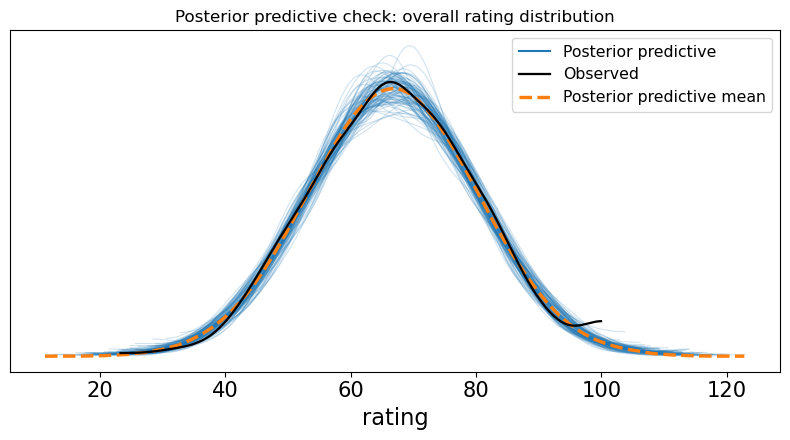

,episode,observed_mean,ppc_mean,ppc_hdi_3%,ppc_hdi_97%
0,Relaxation,65.589,65.564,63.943,67.180
1,Distraction,63.662,63.666,62.041,65.272
2,Enjoyment,68.695,68.683,67.038,70.321
3,Focus,67.995,67.963,66.344,69.526
4,Motivation,67.732,67.733,66.078,69.324


In [14]:
az.plot_ppc(categorical_ppc_idata, num_pp_samples=100, figsize=(8, 4.5))
plt.title("Posterior predictive check: overall rating distribution")
plt.tight_layout()
plt.show()

ppc_episode_means = []
obs_episode_means = model_df.groupby("episode", observed=False)["rating"].mean().reindex(EPISODE_LEVELS)
episode_codes = model_df["episode"].cat.codes.to_numpy()
for episode_index, episode in enumerate(EPISODE_LEVELS):
    mask = episode_codes == episode_index
    draws = ppc_values[:, :, mask].mean(axis=2).reshape(-1)
    ppc_episode_means.append(
        {"episode": episode, "observed_mean": obs_episode_means.loc[episode], "ppc_mean": draws.mean(), "ppc_hdi_3%": np.quantile(draws, 0.03), "ppc_hdi_97%": np.quantile(draws, 0.97)}
    )
ppc_episode_summary = pd.DataFrame(ppc_episode_means).round(3)
display(ppc_episode_summary)

## 12. Effect-Recovery Assessment

The generator's raw treatment-coded effect dictionaries should not be compared one-to-one with fitted treatment-coded coefficients. Instead, recovery is assessed through model-implied Episode x Stimulus cell means.

The exported `expected_rating` column from Notebook 1 is used as the valid synthetic truth source. It represents the generator's expected rating before residual noise. For each Episode x Stimulus cell, the truth target below averages that expected value over participants in the generated dataset.

In [15]:
prediction_grid = pd.DataFrame(
    [(episode, stimulus_id) for episode in EPISODE_LEVELS for stimulus_id in STIMULUS_LEVELS],
    columns=["episode", "stimulus_id"],
)
prediction_grid["participant_id"] = PARTICIPANT_LEVELS[0]
prediction_grid["song_id"] = prediction_grid["stimulus_id"].str.extract(r"(Song_\d)_Mix_\d")
prediction_grid["mix_id"] = prediction_grid["stimulus_id"].str.extract(r"Song_\d_(Mix_\d)")
prediction_grid["group"] = np.where(prediction_grid["song_id"].isin(["Song_1", "Song_2"]), "Group_1", "Group_2")
for column, levels in category_levels.items():
    prediction_grid[column] = pd.Categorical(prediction_grid[column], categories=levels, ordered=False)

cell_mean_idata = categorical_model.predict(categorical_idata, kind="response_params", data=prediction_grid, inplace=False, include_group_specific=False)
mu_draws = cell_mean_idata.posterior["mu"].values
mu_cell_draws = mu_draws.reshape(-1, mu_draws.shape[-1])
true_cell_means = (
    model_df.groupby(["episode", "stimulus_id"], observed=False)["expected_rating"]
    .mean()
    .reindex(pd.MultiIndex.from_frame(prediction_grid[["episode", "stimulus_id"]]))
    .to_numpy()
)
posterior_cell_mean = mu_cell_draws.mean(axis=0)
cell_hdi = az.hdi(mu_cell_draws, hdi_prob=0.94)
recovery_df = prediction_grid[["episode", "song_id", "mix_id", "stimulus_id"]].copy()
recovery_df["true_expected_mean"] = true_cell_means
recovery_df["posterior_mean"] = posterior_cell_mean
recovery_df["hdi_3%"] = cell_hdi[:, 0]
recovery_df["hdi_97%"] = cell_hdi[:, 1]
recovery_df["absolute_error"] = (recovery_df["posterior_mean"] - recovery_df["true_expected_mean"]).abs()
recovery_df["covered_by_94pct_hdi"] = recovery_df["true_expected_mean"].between(recovery_df["hdi_3%"], recovery_df["hdi_97%"])
recovery_rmse = float(np.sqrt(np.mean((recovery_df["posterior_mean"] - recovery_df["true_expected_mean"]) ** 2)))
coverage_rate = float(recovery_df["covered_by_94pct_hdi"].mean())
recovery_summary = pd.DataFrame([{"metric": "cell_mean_RMSE", "value": recovery_rmse}, {"metric": "94pct_HDI_coverage", "value": coverage_rate}]).round(4)
display(recovery_summary)
display(recovery_df.round(3).head(15))

C:\Users\oscar\AppData\Local\Temp\ipykernel_25056\1313620405.py:22: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  cell_hdi = az.hdi(mu_cell_draws, hdi_prob=0.94)


,metric,value
0,cell_mean_RMSE,2.1659
1,94pct_HDI_coverage,0.9500


,episode,song_id,mix_id,stimulus_id,true_expected_mean,posterior_mean,hdi_3%,hdi_97%,absolute_error,covered_by_94pct_hdi
0,Relaxation,Song_1,Mix_1,Song_1_Mix_1,64.876,64.831,60.173,70.277,0.045,True
1,Relaxation,Song_1,Mix_2,Song_1_Mix_2,65.063,63.192,58.213,68.011,1.871,True
2,Relaxation,Song_1,Mix_3,Song_1_Mix_3,59.273,56.897,51.572,61.655,2.376,True
3,Relaxation,Song_2,Mix_1,Song_2_Mix_1,65.596,64.701,59.739,69.633,0.894,True
4,Relaxation,Song_2,Mix_2,Song_2_Mix_2,65.782,67.128,62.326,72.471,1.346,True
5,Relaxation,Song_2,Mix_3,Song_2_Mix_3,59.993,62.238,56.692,66.787,2.245,True
6,Relaxation,Song_3,Mix_1,Song_3_Mix_1,76.064,78.575,73.345,83.659,2.512,True
7,Relaxation,Song_3,Mix_2,Song_3_Mix_2,74.613,74.124,69.120,79.192,0.488,True
8,Relaxation,Song_3,Mix_3,Song_3_Mix_3,70.152,69.882,65.043,75.191,0.270,True
9,Relaxation,Song_4,Mix_1,Song_4_Mix_1,67.214,64.331,59.336,69.184,2.883,True


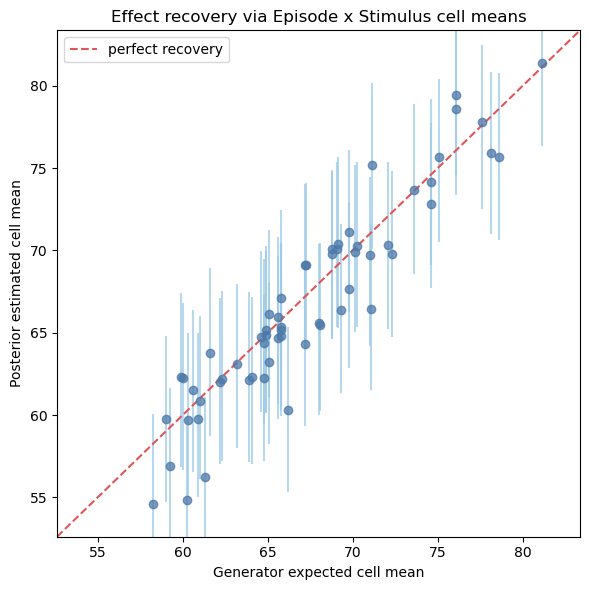

In [16]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.errorbar(
    recovery_df["true_expected_mean"],
    recovery_df["posterior_mean"],
    yerr=[recovery_df["posterior_mean"] - recovery_df["hdi_3%"], recovery_df["hdi_97%"] - recovery_df["posterior_mean"]],
    fmt="o",
    alpha=0.75,
    color="#4C78A8",
    ecolor="#A0CBE8",
)
limits = [
    min(recovery_df["true_expected_mean"].min(), recovery_df["posterior_mean"].min()) - 2,
    max(recovery_df["true_expected_mean"].max(), recovery_df["posterior_mean"].max()) + 2,
]
ax.plot(limits, limits, color="#E15759", linestyle="--", label="perfect recovery")
ax.set_xlim(limits)
ax.set_ylim(limits)
ax.set_title("Effect recovery via Episode x Stimulus cell means")
ax.set_xlabel("Generator expected cell mean")
ax.set_ylabel("Posterior estimated cell mean")
ax.legend()
fig.tight_layout()
plt.show()

## 13. Prediction of Highest-Rated Mix Within Song and Episode

For each song and episode, posterior expected ratings are compared across the three stimuli for that song. The preference probability is the proportion of posterior draws in which each stimulus has the highest expected rating within its song and episode.

In [17]:
prediction_rows = []
prediction_validation_rows = []

for episode in EPISODE_LEVELS:
    for song_id in SONG_LEVELS:
        song_mask = (prediction_grid["episode"].astype(str).eq(episode)) & (prediction_grid["song_id"].astype(str).eq(song_id))
        song_grid_index = np.flatnonzero(song_mask.to_numpy())
        song_draws = mu_cell_draws[:, song_grid_index]

        if song_draws.shape[1] != 3:
            raise ValueError(f"Expected 3 candidate stimuli for {song_id} x {episode}; found {song_draws.shape[1]}.")

        # Draw-by-draw comparison: ties receive fractional credit so probabilities still sum to 1.
        draw_max = song_draws.max(axis=1, keepdims=True)
        draw_winner_mask = np.isclose(song_draws, draw_max, rtol=0.0, atol=1e-12)
        draw_tie_mask = draw_winner_mask.sum(axis=1) > 1
        draw_winner_weights = draw_winner_mask / draw_winner_mask.sum(axis=1, keepdims=True)
        posterior_probabilities = draw_winner_weights.mean(axis=0)
        posterior_tie_probability = float(draw_tie_mask.mean())

        posterior_means = song_draws.mean(axis=0)
        hdi = az.hdi(song_draws, hdi_prob=0.94)

        max_probability = posterior_probabilities.max()
        final_probability_tie_mask = np.isclose(posterior_probabilities, max_probability, rtol=0.0, atol=1e-12)
        has_final_probability_tie = bool(final_probability_tie_mask.sum() > 1)
        if has_final_probability_tie:
            final_winner_local = int(np.flatnonzero(final_probability_tie_mask)[0])
        else:
            final_winner_local = int(np.argmax(posterior_probabilities))

        probability_sum = float(posterior_probabilities.sum())
        prediction_validation_rows.append(
            {
                "song_id": song_id,
                "episode": episode,
                "candidate_stimuli": int(song_draws.shape[1]),
                "probability_sum": probability_sum,
                "probabilities_between_0_and_1": bool(((posterior_probabilities >= 0) & (posterior_probabilities <= 1)).all()),
                "final_probability_tie": has_final_probability_tie,
                "draw_level_tie_probability": posterior_tie_probability,
            }
        )

        for local_index, grid_index in enumerate(song_grid_index):
            row = prediction_grid.iloc[grid_index]
            prediction_rows.append(
                {
                    "song_id": song_id,
                    "episode": episode,
                    "stimulus_id": row["stimulus_id"],
                    "mix_id": row["mix_id"],
                    "posterior_mean_rating": posterior_means[local_index],
                    "hdi_3%": hdi[local_index, 0],
                    "hdi_97%": hdi[local_index, 1],
                    "posterior_probability_highest": float(posterior_probabilities[local_index]),
                    "is_final_predicted_winner": bool(local_index == final_winner_local),
                    "final_probability_tie": has_final_probability_tie,
                    "draw_level_tie_probability": posterior_tie_probability,
                }
            )

predicted_highest_df = pd.DataFrame(prediction_rows).round(4)
prediction_validation_df = pd.DataFrame(prediction_validation_rows)

prediction_checks = pd.DataFrame(
    [
        {
            "check": "three_candidate_stimuli_per_song_episode",
            "passed": prediction_validation_df["candidate_stimuli"].eq(3).all(),
            "observed": prediction_validation_df["candidate_stimuli"].unique().tolist(),
            "expected": 3,
        },
        {
            "check": "probabilities_between_0_and_1",
            "passed": prediction_validation_df["probabilities_between_0_and_1"].all(),
            "observed": "all checked",
            "expected": "0 <= probability <= 1",
        },
        {
            "check": "probabilities_sum_to_approximately_1",
            "passed": np.isclose(prediction_validation_df["probability_sum"], 1.0, atol=1e-10).all(),
            "observed": prediction_validation_df["probability_sum"].round(12).unique().tolist(),
            "expected": 1.0,
        },
        {
            "check": "one_final_winner_per_song_episode_when_no_probability_tie",
            "passed": predicted_highest_df.groupby(["song_id", "episode"])["is_final_predicted_winner"].sum().eq(1).all(),
            "observed": predicted_highest_df.groupby(["song_id", "episode"])["is_final_predicted_winner"].sum().unique().tolist(),
            "expected": 1,
        },
    ]
)

display(predicted_highest_df.head(18))
display(prediction_validation_df.round(6))
display(prediction_checks)
assert prediction_checks["passed"].all()

C:\Users\oscar\AppData\Local\Temp\ipykernel_25056\2079000298.py:22: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi = az.hdi(song_draws, hdi_prob=0.94)
C:\Users\oscar\AppData\Local\Temp\ipykernel_25056\2079000298.py:22: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi = az.hdi(song_draws, hdi_prob=0.94)
C:\Users\oscar\AppData\Local\Temp\ipykernel_25056\2079000298.py:22: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi = az.hdi(song_draws, hdi_prob=0.94)
C:\Users\oscar\AppData\Local\Temp\ipykernel_25056\2079000298.py:22: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for c

,song_id,episode,stimulus_id,mix_id,posterior_mean_rating,hdi_3%,hdi_97%,posterior_probability_highest,is_final_predicted_winner,final_probability_tie,draw_level_tie_probability
0,Song_1,Relaxation,Song_1_Mix_1,Mix_1,64.8313,60.1726,70.2765,0.6992,True,False,0.0
1,Song_1,Relaxation,Song_1_Mix_2,Mix_2,63.1919,58.2132,68.0115,0.2990,False,False,0.0
2,Song_1,Relaxation,Song_1_Mix_3,Mix_3,56.8971,51.5722,61.6551,0.0018,False,False,0.0
3,Song_2,Relaxation,Song_2_Mix_1,Mix_1,64.7012,59.7385,69.6333,0.1968,False,False,0.0
4,Song_2,Relaxation,Song_2_Mix_2,Mix_2,67.1283,62.3259,72.4710,0.7710,True,False,0.0
5,Song_2,Relaxation,Song_2_Mix_3,Mix_3,62.2379,56.6918,66.7869,0.0322,False,False,0.0
6,Song_3,Relaxation,Song_3_Mix_1,Mix_1,78.5755,73.3454,83.6595,0.9180,True,False,0.0
7,Song_3,Relaxation,Song_3_Mix_2,Mix_2,74.1242,69.1198,79.1919,0.0805,False,False,0.0
8,Song_3,Relaxation,Song_3_Mix_3,Mix_3,69.8820,65.0430,75.1914,0.0015,False,False,0.0
9,Song_4,Relaxation,Song_4_Mix_1,Mix_1,64.3307,59.3357,69.1838,0.4360,False,False,0.0


,song_id,episode,candidate_stimuli,probability_sum,probabilities_between_0_and_1,final_probability_tie,draw_level_tie_probability
0,Song_1,Relaxation,3,1.0,True,False,0.0
1,Song_2,Relaxation,3,1.0,True,False,0.0
2,Song_3,Relaxation,3,1.0,True,False,0.0
3,Song_4,Relaxation,3,1.0,True,False,0.0
4,Song_1,Distraction,3,1.0,True,False,0.0
5,Song_2,Distraction,3,1.0,True,False,0.0
6,Song_3,Distraction,3,1.0,True,False,0.0
7,Song_4,Distraction,3,1.0,True,False,0.0
8,Song_1,Enjoyment,3,1.0,True,False,0.0
9,Song_2,Enjoyment,3,1.0,True,False,0.0


,check,passed,observed,expected
0,three_candidate_stimuli_per_song_episode,True,[3],3
1,probabilities_between_0_and_1,True,all checked,0 <= probability <= 1
2,probabilities_sum_to_approximately_1,True,[1.0],1.0
3,one_final_winner_per_song_episode_when_no_prob...,True,[1],1


## 14. In-Sample Fit Caveat

No ordinary predictive accuracy is reported as final performance here because the same observations were used to fit the model. Any in-sample checks in this notebook are apparent fit diagnostics only. Proper participant-level cross-validation will be implemented in a later notebook.

## 15. Export Outputs

Machine-readable summaries are exported without dumping thousands of raw posterior draws to CSV. The fitted `InferenceData` is saved in NetCDF format when practical.

In [18]:
posterior_summary_path = OUTPUT_DIR / "posterior_summary_episode_x_stimulus.csv"
diagnostics_path = OUTPUT_DIR / "convergence_diagnostics.csv"
cell_means_path = OUTPUT_DIR / "episode_stimulus_posterior_means.csv"
recovery_path = OUTPUT_DIR / "effect_recovery_cell_means.csv"
predicted_highest_path = OUTPUT_DIR / "predicted_highest_rated_mixes.csv"
ppc_summary_path = OUTPUT_DIR / "posterior_predictive_summary.csv"
intercept_summary_path = OUTPUT_DIR / "intercept_variance_summary.csv"
idata_path = OUTPUT_DIR / "categorical_episode_x_stimulus_idata.nc"
posterior_summary.to_csv(posterior_summary_path)
combined_diagnostics.to_csv(diagnostics_path, index=False)
recovery_df.to_csv(recovery_path, index=False)
predicted_highest_df.to_csv(predicted_highest_path, index=False)
ppc_summary.to_csv(ppc_summary_path, index=False)
intercept_variance_summary.to_csv(intercept_summary_path, index=False)
cell_means_export = recovery_df[["episode", "song_id", "mix_id", "stimulus_id", "posterior_mean", "hdi_3%", "hdi_97%"]].copy()
cell_means_export.to_csv(cell_means_path, index=False)

def netcdf_safe_attrs(attrs: dict) -> dict:
    safe = {}
    for key, value in attrs.items():
        if isinstance(value, (str, bytes, int, float, np.number, list, tuple, np.ndarray)):
            safe[key] = value
        else:
            safe[key] = json.dumps(value)
    return safe

idata_for_export = categorical_idata.copy()
idata_for_export.attrs = netcdf_safe_attrs(dict(idata_for_export.attrs))
for group_name in idata_for_export.groups():
    group = getattr(idata_for_export, group_name)
    group.attrs = netcdf_safe_attrs(dict(group.attrs))
idata_for_export.to_netcdf(idata_path)
export_manifest = pd.DataFrame(
    [
        {"artifact": "posterior_summary", "path": str(posterior_summary_path.relative_to(REPO_ROOT))},
        {"artifact": "convergence_diagnostics", "path": str(diagnostics_path.relative_to(REPO_ROOT))},
        {"artifact": "episode_stimulus_posterior_means", "path": str(cell_means_path.relative_to(REPO_ROOT))},
        {"artifact": "effect_recovery_cell_means", "path": str(recovery_path.relative_to(REPO_ROOT))},
        {"artifact": "predicted_highest_rated_mixes", "path": str(predicted_highest_path.relative_to(REPO_ROOT))},
        {"artifact": "posterior_predictive_summary", "path": str(ppc_summary_path.relative_to(REPO_ROOT))},
        {"artifact": "intercept_variance_summary", "path": str(intercept_summary_path.relative_to(REPO_ROOT))},
        {"artifact": "categorical_inference_data", "path": str(idata_path.relative_to(REPO_ROOT))},
    ]
)
display(export_manifest)

,artifact,path
0,posterior_summary,outputs\statistical_baseline\categorical_model...
1,convergence_diagnostics,outputs\statistical_baseline\categorical_model...
2,episode_stimulus_posterior_means,outputs\statistical_baseline\categorical_model...
3,effect_recovery_cell_means,outputs\statistical_baseline\categorical_model...
4,predicted_highest_rated_mixes,outputs\statistical_baseline\categorical_model...
5,posterior_predictive_summary,outputs\statistical_baseline\categorical_model...
6,intercept_variance_summary,outputs\statistical_baseline\categorical_model...
7,categorical_inference_data,outputs\statistical_baseline\categorical_model...


## 16. Execution Summary

This cell records the main execution metrics for the notebook handoff.

In [19]:
max_rhat = float(posterior_summary["r_hat"].max(skipna=True))
min_ess = float(min(posterior_summary["ess_bulk"].min(skipna=True), posterior_summary["ess_tail"].min(skipna=True)))
divergences = int(categorical_idata.sample_stats["diverging"].sum().item()) if "diverging" in categorical_idata.sample_stats else 0
execution_summary = pd.DataFrame(
    [
        {"item": "notebook", "value": "notebooks/Statistical Baseline/_02_categorical_stimulus_model.ipynb"},
        {"item": "primary_formula", "value": "rating ~ episode * stimulus_id + (1 | participant_id)"},
        {"item": "comparison_formula", "value": "rating ~ 1 + (1 | participant_id)"},
        {"item": "sampling", "value": json.dumps(SAMPLING_CONFIG)},
        {"item": "intercept_model_elapsed_minutes", "value": round(intercept_elapsed_seconds / 60, 3)},
        {"item": "categorical_model_elapsed_minutes", "value": round(categorical_elapsed_seconds / 60, 3)},
        {"item": "divergences", "value": divergences},
        {"item": "maximum_rhat", "value": round(max_rhat, 4)},
        {"item": "minimum_effective_sample_size", "value": round(min_ess, 1)},
        {"item": "posterior_predictive_outside_0_100_proportion", "value": round(ppc_boundary_violation_rate, 6)},
        {"item": "effect_recovery_rmse", "value": round(recovery_rmse, 4)},
        {"item": "cell_mean_94pct_hdi_coverage", "value": round(coverage_rate, 4)},
    ]
)
display(execution_summary)
execution_summary.to_csv(OUTPUT_DIR / "execution_summary.csv", index=False)

,item,value
0,notebook,notebooks/Statistical Baseline/_02_categorical...
1,primary_formula,rating ~ episode * stimulus_id + (1 | particip...
2,comparison_formula,rating ~ 1 + (1 | participant_id)
3,sampling,"{""draws"": 1000, ""tune"": 1000, ""chains"": 4, ""co..."
4,intercept_model_elapsed_minutes,0.112
5,categorical_model_elapsed_minutes,0.146
6,divergences,0
7,maximum_rhat,1.012
8,minimum_effective_sample_size,498.7
9,posterior_predictive_outside_0_100_proportion,0.00655


## 17. Limitations and Next Steps

- The data are synthetic; model estimates are not empirical findings about real participants or real mix preferences.
- The model is stimulus-specific: it predicts the twelve known study stimuli rather than generalising to arbitrary new audio stimuli.
- Arbitrary neutral mix identifiers are not interpreted across songs.
- This categorical model cannot identify which MST feature drives preference.
- Gaussian boundary behaviour must be checked because the likelihood can generate ratings below 0 or above 100.
- Participant-level cross-validation is still required before making baseline performance claims.
- The next Phase 3B notebook will inspect and prepare the MST features.
- BS currently has no agreed scalar representation; the repository stores Bark-spectrum information as a multidimensional mid/side feature vector.